This code bootstraps wind data by cluster

In [1]:
import numpy as np
import pandas as pd, os, datetime
import statsmodels.api as sm
import statsmodels.formula.api as smf

# Statistical analysis
from typing import Sequence, Tuple, Optional
from joblib import Parallel, delayed
from scipy import stats
import math

# plottinng
import matplotlib.pyplot as plt

# Import the loader function
os.chdir('/g/data/ng72/ms5578/ID_HW_BARRA')
from process_code import load_generation_data

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that installed pynvml for you.
  import pynvml
/g/data/xp65/public/apps/med_conda/envs/analysis3-25.12/lib/python3.11/site-packages/distributed/diagnostics/nvml.py:14: FutureWarning: The pynvml package is deprecated. Please install nvidia-ml-py instead. If you did not install pynvml directly, please report this to the maintainers of the package that i

Dask dashboard: /proxy/8787/status


2025-12-15 10:08:31,639 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle cee544f46277e03a913ec0f30b38a86e initialized by task ('shuffle-transfer-cee544f46277e03a913ec0f30b38a86e', 1) executed on worker tcp://127.0.0.1:36819
2025-12-15 10:08:42,591 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle cee544f46277e03a913ec0f30b38a86e deactivated due to stimulus 'task-finished-1765753722.5846732'
2025-12-15 10:08:43,088 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle d2bf34415c6f40f73dd94d7619c24bee initialized by task ('shuffle-transfer-d2bf34415c6f40f73dd94d7619c24bee', 0) executed on worker tcp://127.0.0.1:36819
2025-12-15 10:08:45,579 - distributed.shuffle._scheduler_plugin - WARNING - Shuffle d2bf34415c6f40f73dd94d7619c24bee deactivated due to stimulus 'task-finished-1765753725.319236'


In [2]:
clust_map = pd.read_csv("data/preprocess/wind_spatial_clusters.csv")

In [3]:
data, info = load_generation_data(
    sdate="2009-07-01",
    edate="2024-06-30",
    mode="hourly",
    ftype=["Wind"],
    apply_remove_negatives=True,
    apply_remove_wind_zeros=True,
    wind_zero_threshold=40,
    apply_min_heatwave_days=True,
    min_heatwave_days_threshold=20,
    apply_clear_agc=False
)

Read gen_details & hw_tseries with Dask: 0.03 sec
Select group: 0.00 sec
--- Starting Dask-Native Process ---


/g/data/ng72/ms5578/ID_HW_BARRA/process_code.py:168: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  grp_pd_jittered = grp_pd.groupby(['lat', 'lon'], group_keys=False).apply(


Starting final Dask compute...
Dask compute finished.

--- DASK TIMING REPORT ---
duid_setup: 0.00 seconds
csv_bulk_read: 0.18 seconds
filter_and_clean: 0.01 seconds
type_conversion_and_dropna: 0.02 seconds
date_filter: 0.01 seconds
hw_tseries_filter: 11.02 seconds
aggregate_hourly: 0.03 seconds
jitter: 0.22 seconds
final_merge: 0.02 seconds
compute: 71.16 seconds
--- END REPORT ---

Process group: 86.59 sec

--- DEBUG: Calculated Heatwave Days per Generator ---
DUID
MUSSELR1    334
SAPHWF1     206
WRWF1       201
HALLWF2     187
HALLWF1     187
GUNNING1    178
WOODLWN1    171
LKBONNY2    168
GULLRWF1    164
NBHWF1      162
WATERLWF    161
CLEMGPWF    158
SNOWTWN1    157
LKBONNY3    157
BLUFF1      151
TARALGA1    150
MEWF1       143
BOCORWF1    126
BODWF1      122
STWF1       115
SNOWNTH1    109
OAKLAND1    108
COOPGWF1    103
BALDHWF1    101
MACARTH1     98
HDWF1        98
HDWF2        92
HDWF3        92
SNOWSTH1     89
MERCER01     84
GRANWF1      84
CROOKWF2     76
ARWF1        72


Append clusters to generation timeseries in tidy format

In [4]:
df = pd.merge(data,clust_map[['DUID','cluster']], on='DUID', how='left').sort_values(['EHF_flag','cluster','DUID','time'])

Z-score normalise by cluster.

In [5]:
df['z_score'] = df.groupby('DUID')['TOTALMWh'].transform(
    lambda x: (x - x.mean()) / x.std(ddof=1)
)
df

,DUID,time,TOTALMWh,TOTALCLEARED,AGCSTATUS,lat,lon,tas,EHF_val,HW_EHF_avg,...,tas_3d_peak,event_group,HW_event_day,date,fuel_source_primary,region,lat_jittered,lon_jittered,cluster,z_score
66875,BALDHWF1,2015-01-29 00:00:00+00:00,0.0,0.0,0,-38.83,145.90,288.815674,0.000000,NaN,...,NaN,NaN,NaN,2015-01-29 00:00:00+00:00,Wind,VIC1,-38.790800,145.927700,0,-1.002993
66876,BALDHWF1,2015-01-29 01:00:00+00:00,0.0,0.0,0,-38.83,145.90,288.815674,0.000000,NaN,...,NaN,NaN,NaN,2015-01-29 00:00:00+00:00,Wind,VIC1,-38.790800,145.927700,0,-1.002993
66877,BALDHWF1,2015-01-29 02:00:00+00:00,0.0,0.0,0,-38.83,145.90,288.815674,0.000000,NaN,...,NaN,NaN,NaN,2015-01-29 00:00:00+00:00,Wind,VIC1,-38.790800,145.927700,0,-1.002993
66878,BALDHWF1,2015-01-29 03:00:00+00:00,0.0,0.0,0,-38.83,145.90,288.815674,0.000000,NaN,...,NaN,NaN,NaN,2015-01-29 00:00:00+00:00,Wind,VIC1,-38.790800,145.927700,0,-1.002993
66879,BALDHWF1,2015-01-29 04:00:00+00:00,0.0,0.0,0,-38.83,145.90,288.815674,0.000000,NaN,...,NaN,NaN,NaN,2015-01-29 00:00:00+00:00,Wind,VIC1,-38.790800,145.927700,0,-1.002993
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3620852,YENDWF1,2024-03-12 19:00:00+00:00,11.761667,11.923001,0,-37.62,144.03,289.466064,7.529788,21.464111,...,299.865234,70.0,4.0,2024-03-12 00:00:00+00:00,Wind,VIC1,-37.631438,144.020788,5,-0.637804
3620853,YENDWF1,2024-03-12 20:00:00+00:00,20.029167,19.391524,0,-37.62,144.03,289.466064,7.529788,21.464111,...,299.865234,70.0,4.0,2024-03-12 00:00:00+00:00,Wind,VIC1,-37.631438,144.020788,5,-0.435582
3620854,YENDWF1,2024-03-12 21:00:00+00:00,25.305,24.621204,0,-37.62,144.03,289.466064,7.529788,21.464111,...,299.865234,70.0,4.0,2024-03-12 00:00:00+00:00,Wind,VIC1,-37.631438,144.020788,5,-0.306536
3620855,YENDWF1,2024-03-12 22:00:00+00:00,31.734166,30.716528,0,-37.62,144.03,289.466064,7.529788,21.464111,...,299.865234,70.0,4.0,2024-03-12 00:00:00+00:00,Wind,VIC1,-37.631438,144.020788,5,-0.14928


In [6]:
def bootstrap_curve(
    X: np.ndarray,
    n_boot: int,
    batch_size: Optional[int] = None,
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Bootstrap mean and median daily curves with confidence intervals, batched for speed and memory.

    Parameters
    ----------
    X : np.ndarray
        Array of shape (n_days, n_hours)
    n_boot : int
        Number of bootstrap samples
    batch_size : Optional[int]
        Number of bootstrap samples to process per batch. If None, chosen automatically.
    seed : int
        RNG seed for reproducibility

    Returns
    -------
    mean_curve : np.ndarray, shape (n_hours,)
    mean_lower : np.ndarray, shape (n_hours,)
    mean_upper : np.ndarray, shape (n_hours,)
    median_curve : np.ndarray, shape (n_hours,)
    median_lower : np.ndarray, shape (n_hours,)
    median_upper : np.ndarray, shape (n_hours,)
    """
    n_days, n_hours = X.shape
    curves_mean = np.empty((n_boot, n_hours), dtype=np.float64)
    curves_median = np.empty((n_boot, n_hours), dtype=np.float64)
    rng = np.random.default_rng(seed)

    # Choose a batch size that keeps memory reasonable
    if batch_size is None:
        # Aim for ~50–200 MB peak for the 3D array; adjust as needed
        # Each float64 ~8 bytes -> batch_size * n_days * n_hours * 8 bytes
        target_bytes = 100 * 1024 * 1024  # 100 MB
        approx_bs = max(1, int(target_bytes / (n_days * n_hours * 8)))
        batch_size = min(n_boot, max(100, approx_bs))

    out_start = 0
    while out_start < n_boot:
        k = min(batch_size, n_boot - out_start)
        # Indices: shape (k, n_days)
        idx = rng.integers(0, n_days, size=(k, n_days))
        # Samples: shape (k, n_days, n_hours)
        samples = X[idx]
        # Aggregate across days -> shape (k, n_hours)
        curves_mean[out_start:out_start + k] = samples.mean(axis=1)
        curves_median[out_start:out_start + k] = np.median(samples, axis=1)
        out_start += k

    # Compute mean and 95% CI across bootstrap replicates
    mean_curve = curves_mean.mean(axis=0)
    mean_lower = np.percentile(curves_mean, 2.5, axis=0)
    mean_upper = np.percentile(curves_mean, 97.5, axis=0)

    # Median curve is the median across bootstrap medians
    median_curve = np.median(curves_median, axis=0)
    median_lower = np.percentile(curves_median, 2.5, axis=0)
    median_upper = np.percentile(curves_median, 97.5, axis=0)

    return mean_curve, mean_lower, mean_upper, median_curve, median_lower, median_upper

In [7]:
def prepare_daily_matrix(
    df: pd.DataFrame,
    value_col: str,
    time_col: str = "time",
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Convert a long time series into a (n_days, n_hours) matrix and hour labels.
    Returns:
        X : ndarray shape (n_days, n_hours)
        hours : ndarray of hour labels (e.g. 0..23)
    """
    if df.empty:
        return np.empty((0, 0)), np.array([], dtype=int)

    tmp = df.copy()
    tmp["day"] = tmp[time_col].dt.floor("D")
    tmp["hour"] = tmp[time_col].dt.hour

    daily = (
        tmp.pivot_table(index="day", columns="hour", values=value_col)
           .dropna()
           .sort_index()
    )

    if daily.empty:
        return np.empty((0, 0)), np.array(sorted(tmp["hour"].unique()), dtype=int)

    X = daily.to_numpy()
    hours = daily.columns.to_numpy()
    return X, hours

In [8]:
def bootstrap_group(
    name,
    gdf: pd.DataFrame,
    value_col: str = "z_score",
    n_boot: int = 1000,
    batch_size: Optional[int] = None,
    seed: int = 42,
):
    """
    Apply bootstrap_curve to a single group.
    Returns:
        group key (name), curves tuple, hour_labels (array)
    """
    X, hour_labels = prepare_daily_matrix(gdf, value_col=value_col, time_col="time")

    # Handle groups with no valid days
    if X.size == 0 or X.shape[0] == 0:
        n_hours = len(hour_labels)
        empty = np.full(n_hours, np.nan)
        return name, (empty, empty, empty, empty, empty, empty), hour_labels

    curves = bootstrap_curve(X, n_boot=n_boot, batch_size=batch_size, seed=seed)
    return name, curves, hour_labels

In [9]:
def _bootstrap_diff_curves(
    X1: np.ndarray,
    X0: np.ndarray,
    n_boot: int,
    batch_size: Optional[int] = None,
    seed: int = 42,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Bootstrap the difference in mean/median daily curves: (EHF=1) - (EHF=0).

    X1 : array for EHF_flag == 1, shape (n_days1, n_hours)
    X0 : array for EHF_flag == 0, shape (n_days0, n_hours)
    """
    n_days1, n_hours1 = X1.shape
    n_days0, n_hours0 = X0.shape
    if n_hours1 != n_hours0:
        raise ValueError("X1 and X0 must have same number of hours (columns)")
    n_hours = n_hours1

    curves_mean_diff = np.empty((n_boot, n_hours), dtype=np.float64)
    curves_median_diff = np.empty((n_boot, n_hours), dtype=np.float64)
    rng = np.random.default_rng(seed)

    # Choose a batch size that keeps memory reasonable
    if batch_size is None:
        target_bytes = 100 * 1024 * 1024  # 100 MB
        # Approximate size using the larger of n_days1, n_days0
        max_days = max(n_days1, n_days0)
        approx_bs = max(1, int(target_bytes / (max_days * n_hours * 8)))
        batch_size = min(n_boot, max(100, approx_bs))

    out_start = 0
    while out_start < n_boot:
        k = min(batch_size, n_boot - out_start)

        # Sample days with replacement for each condition
        idx1 = rng.integers(0, n_days1, size=(k, n_days1))
        idx0 = rng.integers(0, n_days0, size=(k, n_days0))

        s1 = X1[idx1]  # shape (k, n_days1, n_hours)
        s0 = X0[idx0]  # shape (k, n_days0, n_hours)

        mean1 = s1.mean(axis=1)
        mean0 = s0.mean(axis=1)
        med1 = np.median(s1, axis=1)
        med0 = np.median(s0, axis=1)

        curves_mean_diff[out_start:out_start + k] = mean1 - mean0
        curves_median_diff[out_start:out_start + k] = med1 - med0

        out_start += k

    # Summaries and 95% CIs
    mean_diff = curves_mean_diff.mean(axis=0)
    mean_diff_lower = np.percentile(curves_mean_diff, 2.5, axis=0)
    mean_diff_upper = np.percentile(curves_mean_diff, 97.5, axis=0)

    median_diff = np.median(curves_median_diff, axis=0)
    median_diff_lower = np.percentile(curves_median_diff, 2.5, axis=0)
    median_diff_upper = np.percentile(curves_median_diff, 97.5, axis=0)

    return (
        mean_diff,
        mean_diff_lower,
        mean_diff_upper,
        median_diff,
        median_diff_lower,
        median_diff_upper,
    )

In [10]:
def bootstrap_duid_diff(
    df: pd.DataFrame,
    value_col: str = "z_score",
    n_boot: int = 1000,
    batch_size: Optional[int] = None,
    seed: int = 42,
    parallel: bool = True,
    n_jobs: int = -1,
    backend: str = "loky",
    prefer: Optional[str] = None,
) -> pd.DataFrame:
    """
    For each DUID, bootstrap the difference in daily curves between EHF_flag=1 and EHF_flag=0:
        (EHF=1) - (EHF=0)

    Returns columns:
        ['cluster','DUID','hour',
         'mean_diff','mean_diff_lower','mean_diff_upper',
         'median_diff','median_diff_lower','median_diff_upper']
    """
    required = {"time", "EHF_flag", "DUID", value_col}
    missing = [c for c in required if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    grouped = df.groupby("DUID", sort=False)

    if parallel:
        tasks = (
            delayed(_bootstrap_duid_diff_one)(
                duid,
                gdf,
                value_col=value_col,
                n_boot=n_boot,
                batch_size=batch_size,
                seed=seed,
            )
            for duid, gdf in grouped
        )
        results = Parallel(n_jobs=n_jobs, backend=backend, prefer=prefer)(tasks)
        # flatten list of lists
        rows = [row for sub in results for row in sub]
    else:
        rows = []
        for duid, gdf in grouped:
            rows.extend(
                _bootstrap_duid_diff_one(
                    duid,
                    gdf,
                    value_col=value_col,
                    n_boot=n_boot,
                    batch_size=batch_size,
                    seed=seed,
                )
            )

    return pd.DataFrame(rows)

In [11]:
def _bootstrap_duid_diff_one(
    duid: str,
    gdf: pd.DataFrame,
    value_col: str,
    n_boot: int,
    batch_size: Optional[int],
    seed: int,
) -> list[dict]:
    """Worker: compute EHF=1 − EHF=0 difference curves for a single DUID."""
    rows: list[dict] = []

    g1 = gdf[gdf["EHF_flag"] == 1]
    g0 = gdf[gdf["EHF_flag"] == 0]

    X1, hours1 = prepare_daily_matrix(g1, value_col=value_col, time_col="time")
    X0, hours0 = prepare_daily_matrix(g0, value_col=value_col, time_col="time")

    cluster_val = gdf["cluster"].iloc[0] if "cluster" in gdf.columns else None

    # If either side has no valid days, output NaNs for the available hours
    if X1.size == 0 or X0.size == 0:
        hours = np.union1d(hours1, hours0)
        for h in hours:
            rows.append(
                {
                    "cluster": cluster_val,
                    "DUID": duid,
                    "hour": int(h),
                    "mean_diff": np.nan,
                    "mean_diff_lower": np.nan,
                    "mean_diff_upper": np.nan,
                    "median_diff": np.nan,
                    "median_diff_lower": np.nan,
                    "median_diff_upper": np.nan,
                }
            )
        return rows

    # Align hours (use intersection)
    common_hours = np.intersect1d(hours1, hours0)
    if common_hours.size == 0:
        return rows  # nothing to add

    if not np.array_equal(hours1, common_hours):
        X1 = (
            pd.DataFrame(X1, columns=hours1)
            .reindex(columns=common_hours)
            .to_numpy()
        )
    if not np.array_equal(hours0, common_hours):
        X0 = (
            pd.DataFrame(X0, columns=hours0)
            .reindex(columns=common_hours)
            .to_numpy()
        )

    # Optional: make seed DUID‑specific for reproducibility without identical draws
    local_seed = seed + (hash(duid) % 1_000_000)

    (
        mean_diff,
        mean_diff_lower,
        mean_diff_upper,
        median_diff,
        median_diff_lower,
        median_diff_upper,
    ) = _bootstrap_diff_curves(
        X1,
        X0,
        n_boot=n_boot,
        batch_size=batch_size,
        seed=local_seed,
    )

    for i, h in enumerate(common_hours):
        rows.append(
            {
                "cluster": cluster_val,
                "DUID": duid,
                "hour": int(h),
                "mean_diff": float(mean_diff[i]),
                "mean_diff_lower": float(mean_diff_lower[i]),
                "mean_diff_upper": float(mean_diff_upper[i]),
                "median_diff": float(median_diff[i]),
                "median_diff_lower": float(median_diff_lower[i]),
                "median_diff_upper": float(median_diff_upper[i]),
            }
        )
    return rows


In [12]:
def _results_to_dataframe(
    results,
    group_cols: Sequence[str],
) -> pd.DataFrame:
    """
    Convert list of (name, curves, hour_labels) into a tidy DataFrame.
    """
    rows = []
    for name, curves, hour_labels in results:
        mean_curve, mean_lower, mean_upper, median_curve, median_lower, median_upper = curves

        if isinstance(name, tuple):
            key_map = dict(zip(group_cols, name))
        else:
            key_map = {group_cols[0]: name}

        for i, hour in enumerate(hour_labels):
            rows.append(
                {
                    **key_map,
                    "hour": int(hour),
                    "mean": float(mean_curve[i]) if np.isfinite(mean_curve[i]) else np.nan,
                    "mean_lower": float(mean_lower[i]) if np.isfinite(mean_lower[i]) else np.nan,
                    "mean_upper": float(mean_upper[i]) if np.isfinite(mean_upper[i]) else np.nan,
                    "median": float(median_curve[i]) if np.isfinite(median_curve[i]) else np.nan,
                    "median_lower": float(median_lower[i]) if np.isfinite(median_lower[i]) else np.nan,
                    "median_upper": float(median_upper[i]) if np.isfinite(median_upper[i]) else np.nan,
                }
            )
    return pd.DataFrame(rows)

In [13]:
def run_grouped_bootstrap(
    df: pd.DataFrame,
    value_col: str = "z_score",
    n_boot: int = 1000,
    group_cols: Sequence[str] = ("cluster", "DUID", "EHF_flag"),
    parallel: bool = True,
    n_jobs: int = -1,
    backend: str = "loky",
    prefer: Optional[str] = None,
    batch_size: Optional[int] = None,
    seed: int = 42,
) -> pd.DataFrame:
    """
    High-level function to compute bootstrapped curves by group.

    Parameters
    ----------
    df : DataFrame
        Must contain `time`, `value_col`, and `group_cols`.
    parallel : bool
        If True, use joblib.Parallel; otherwise run in a single process.
    """
    needed = set(group_cols) | {"time", value_col}
    missing = [c for c in needed if c not in df.columns]
    if missing:
        raise ValueError(f"Missing required columns: {missing}")

    grouped = df.groupby(list(group_cols), sort=False)

    if parallel:
        tasks = (
            delayed(bootstrap_group)(
                name,
                gdf,
                value_col=value_col,
                n_boot=n_boot,
                batch_size=batch_size,
                seed=seed,
            )
            for name, gdf in grouped
        )

        results = Parallel(n_jobs=n_jobs, backend=backend, prefer=prefer)(tasks)
    else:
        results = [
            bootstrap_group(
                name,
                gdf,
                value_col=value_col,
                n_boot=n_boot,
                batch_size=batch_size,
                seed=seed,
            )
            for name, gdf in grouped
        ]

    return _results_to_dataframe(results, group_cols)

Here is where the grouping, value, and number of bootstraps is specified.

In [14]:
diff_results = bootstrap_duid_diff(df, value_col="z_score", n_boot=1000, parallel=True, n_jobs=-1)

In [15]:
diff_results

,cluster,DUID,hour,mean_diff,mean_diff_lower,mean_diff_upper,median_diff,median_diff_lower,median_diff_upper
0,0,BALDHWF1,0,-0.083182,-0.225325,0.073682,0.043341,-0.168282,0.290777
1,0,BALDHWF1,1,-0.082646,-0.221185,0.076310,0.061072,-0.112051,0.338458
2,0,BALDHWF1,2,-0.095219,-0.239564,0.059503,0.062077,-0.213004,0.381907
3,0,BALDHWF1,3,-0.127696,-0.262735,0.024942,-0.019999,-0.254678,0.321962
4,0,BALDHWF1,4,-0.176048,-0.311700,-0.022575,-0.089591,-0.275562,0.188489
...,...,...,...,...,...,...,...,...,...
1315,5,YENDWF1,19,-0.339548,-0.518353,-0.151208,-0.249429,-0.423626,0.023575
1316,5,YENDWF1,20,-0.089418,-0.325737,0.166287,0.048288,-0.177080,0.217893
1317,5,YENDWF1,21,-0.045598,-0.307636,0.243289,-0.071300,-0.243667,0.465543
1318,5,YENDWF1,22,-0.112886,-0.381374,0.194087,-0.113881,-0.364885,0.221592


In [16]:
def plot_duid_diffs_faceted(
    df_duid_diff: pd.DataFrame,
    cluster_name,
    metric: str = "mean",
    ncols: int = 4,
):
    """
    Plot DUID-level difference curves (EHF=1 - EHF=0) in a faceted layout
    for all DUIDs in a given cluster.

    Parameters
    ----------
    df_duid_diff : DataFrame
        Expected columns:
        ['cluster','DUID','hour',
         'mean_diff','mean_diff_lower','mean_diff_upper',
         'median_diff','median_diff_lower','median_diff_upper']
    cluster_name : hashable
        Cluster identifier to filter.
    metric : str
        'mean' or 'median' (selects mean_diff vs median_diff).
    ncols : int
        Number of columns in the facet grid.
    """
    if metric not in ["mean", "median"]:
        raise ValueError("metric must be 'mean' or 'median'")

    # Map metric -> column base names
    if metric == "mean":
        val_col = "mean_diff"
        lower_col = "mean_diff_lower"
        upper_col = "mean_diff_upper"
        color = "purple"
    else:
        val_col = "median_diff"
        lower_col = "median_diff_lower"
        upper_col = "median_diff_upper"
        color = "teal"

    cdf = df_duid_diff[df_duid_diff["cluster"] == cluster_name].copy()
    if cdf.empty:
        raise ValueError(f"No diff data for cluster {cluster_name}")

    duids = sorted(cdf["DUID"].unique())
    n_duids = len(duids)

    nrows = int(np.ceil(n_duids / ncols))
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.0 * ncols, 3.0 * nrows),
        sharex=True,
        sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    for ax_idx, duid in enumerate(duids):
        ax = axes[ax_idx]
        df_d = cdf[cdf["DUID"] == duid].sort_values("hour")

        y = df_d[val_col].values
        lower = df_d[lower_col].values
        upper = df_d[upper_col].values

        ax.plot(df_d["hour"], y, color=color, label="EHF=1 − EHF=0")
        ax.fill_between(df_d["hour"], lower, upper, color=color, alpha=0.25)

        ax.axhline(0.0, color="black", linewidth=0.8, linestyle="--", alpha=0.6)
        ax.set_title(str(duid), fontsize=(8 + nrows + ncols))

        hours = range(0, 24,3)
        labels = [f"{h:02d}:00" for h in hours]
        
        ax.tick_params(axis='y', labelsize=(8 + nrows + ncols), length=6, width=1.0)
        
        ax.set_xticks(hours)
        ax.set_xticklabels(labels, rotation=315, ha="left", fontsize=(8 + nrows + ncols))
        ax.grid(True, alpha=0.2)

    # Remove unused axes if any
    for ax in axes[n_duids:]:
        ax.remove()

    fig.text(0.5, 0.01, "Hour of Day", ha="center", fontsize= 8+(ncols*2 + nrows))
    fig.text(0.02, 0.5, f"{metric.capitalize()} difference in z-score", va="center", rotation="vertical",
            fontsize=8+(nrows*2 + ncols))

    plt.tight_layout(rect=[0.03, 0.05, 1, 0.94])
    plt.show()

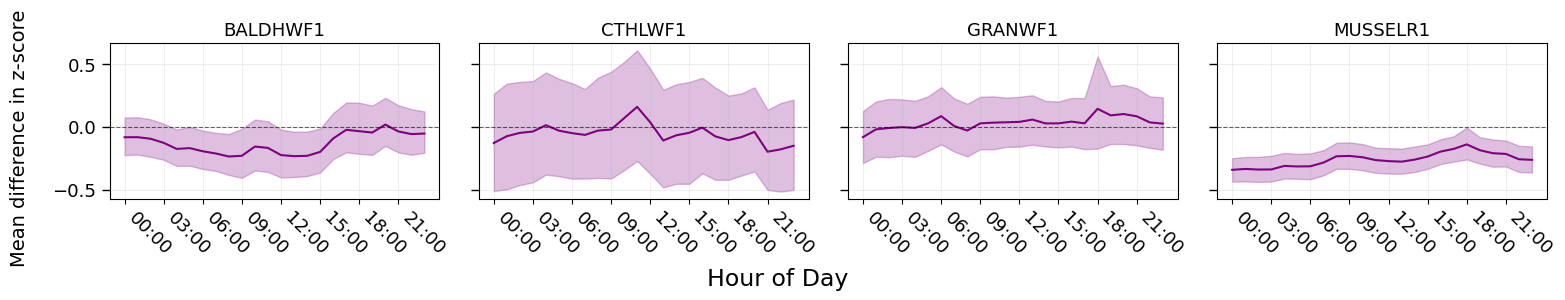

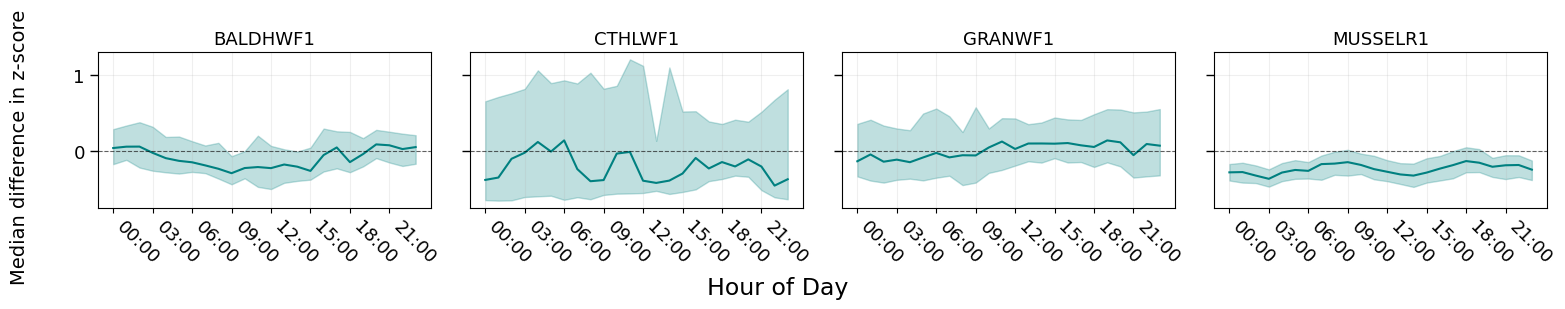

In [17]:
plot_duid_diffs_faceted(diff_results, cluster_name=0, metric="mean")
plot_duid_diffs_faceted(diff_results, cluster_name=0, metric="median")

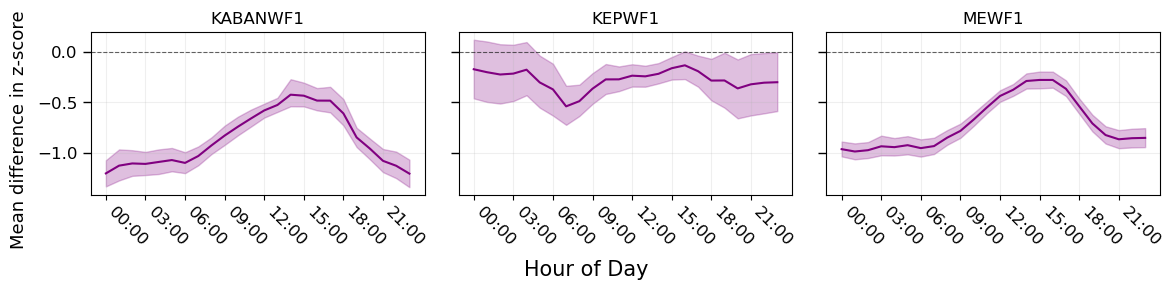

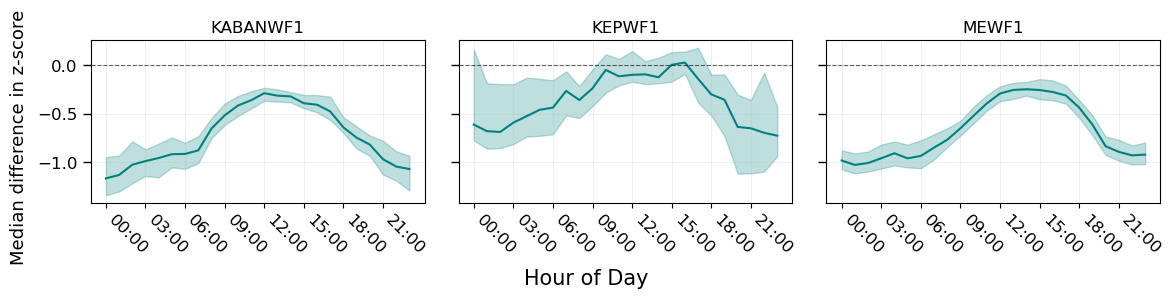

In [18]:
plot_duid_diffs_faceted(diff_results, ncols=3, cluster_name=1, metric="mean")
plot_duid_diffs_faceted(diff_results, ncols=3, cluster_name=1, metric="median")

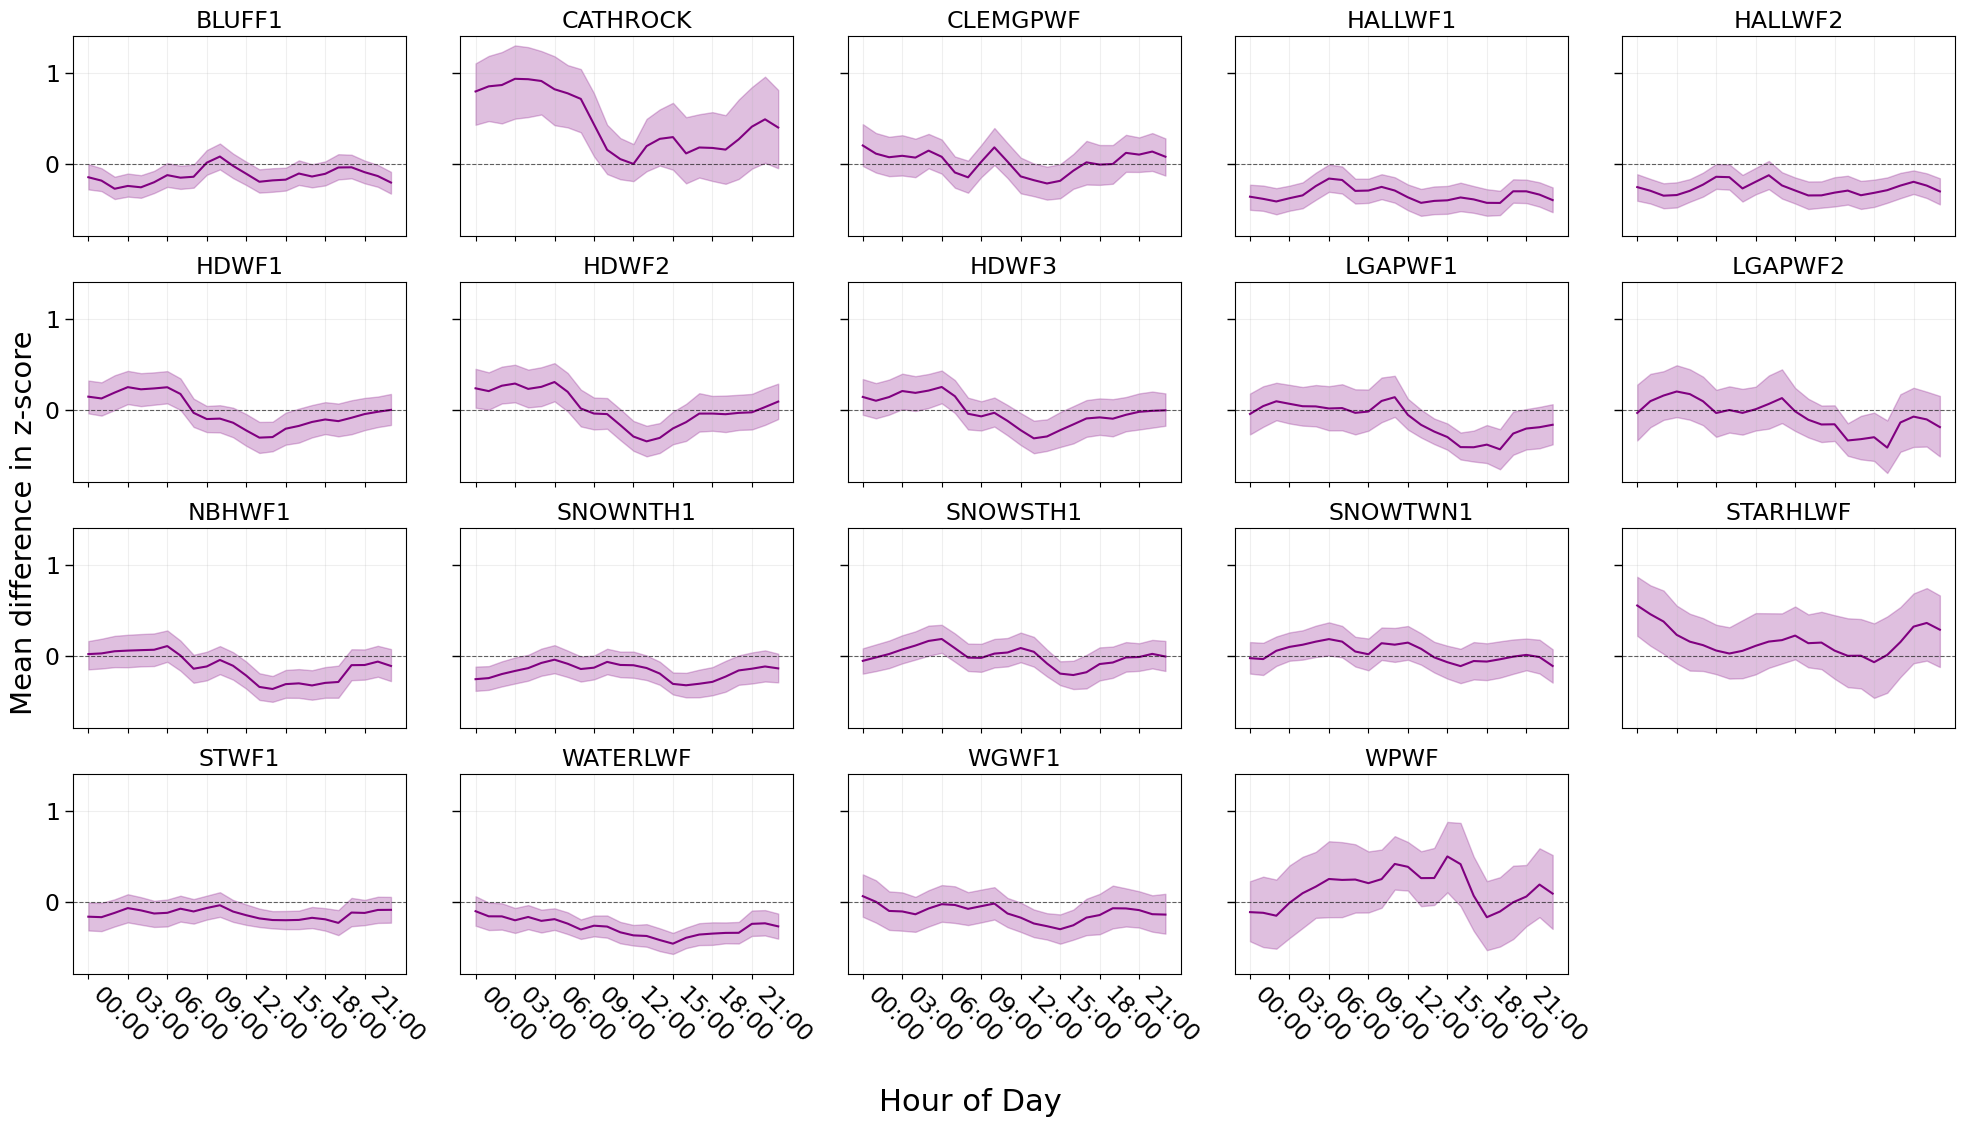

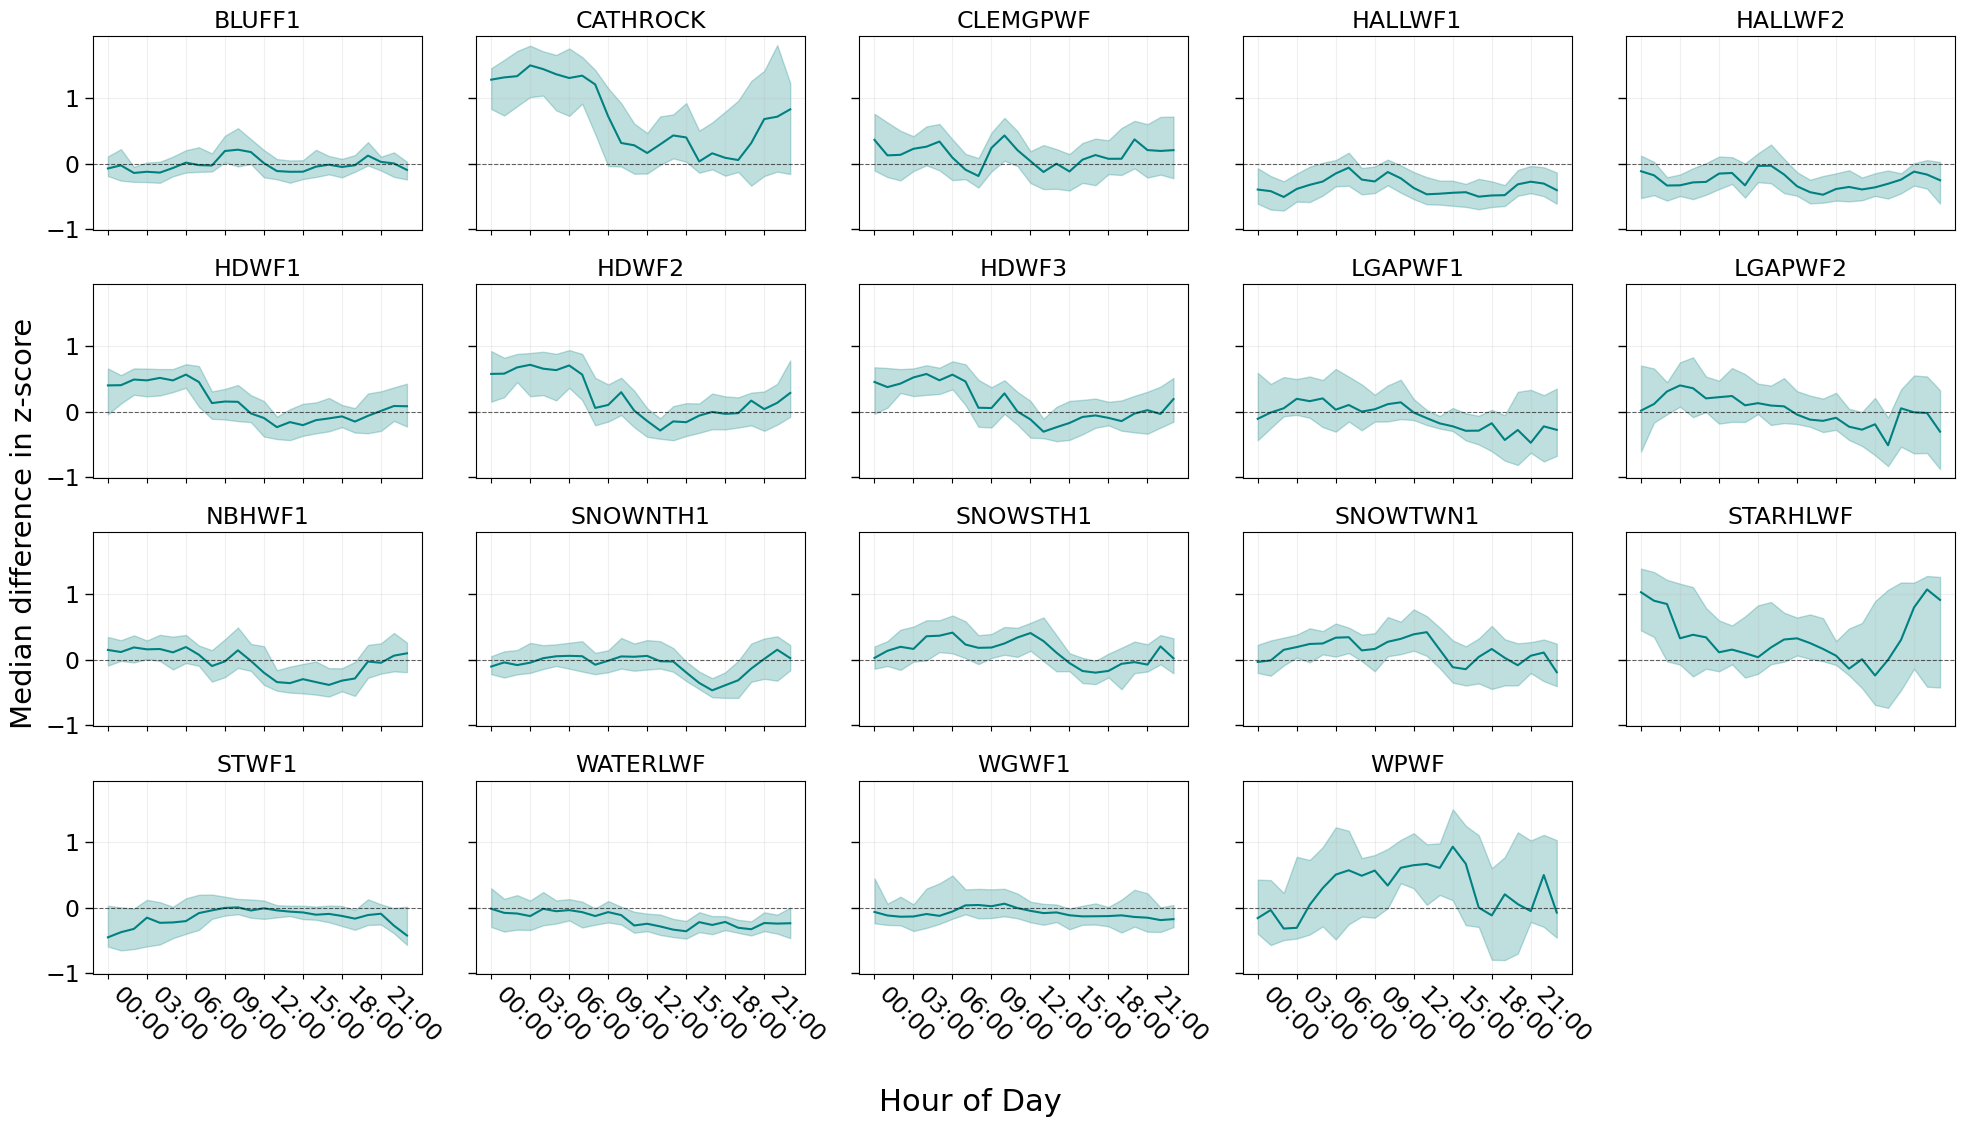

In [19]:
plot_duid_diffs_faceted(diff_results, ncols=5, cluster_name=2, metric="mean")
plot_duid_diffs_faceted(diff_results, ncols=5, cluster_name=2, metric="median")

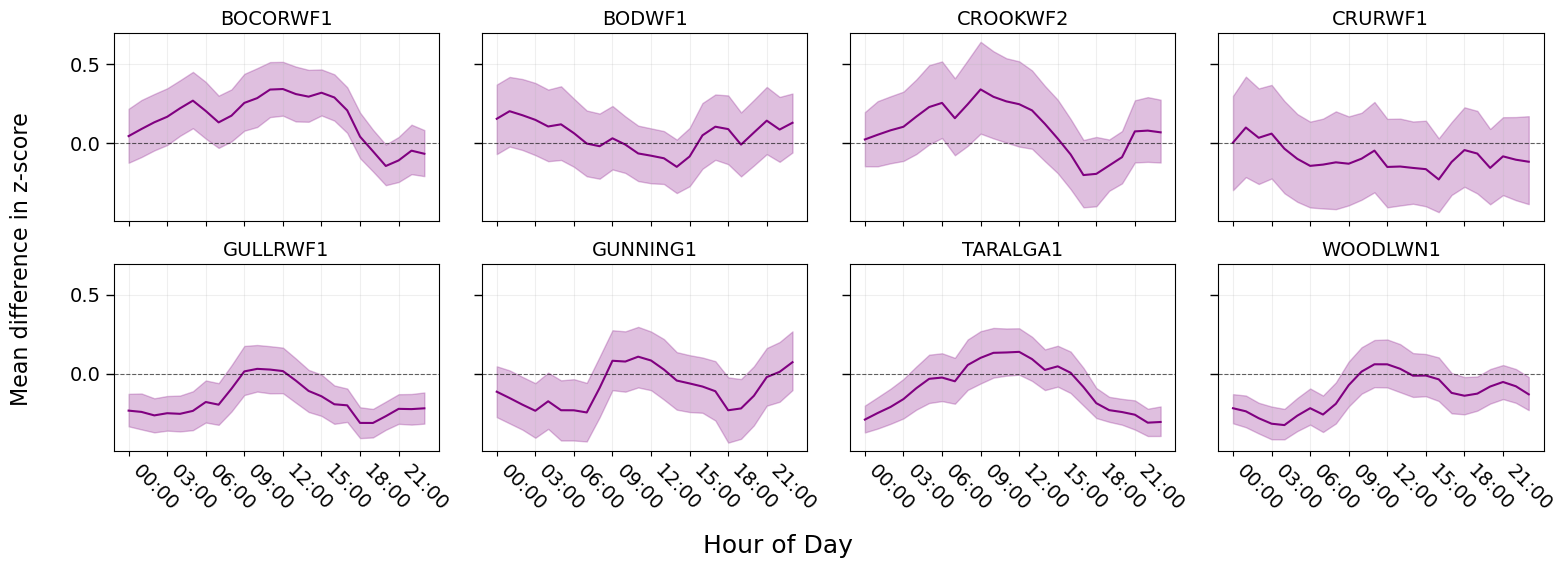

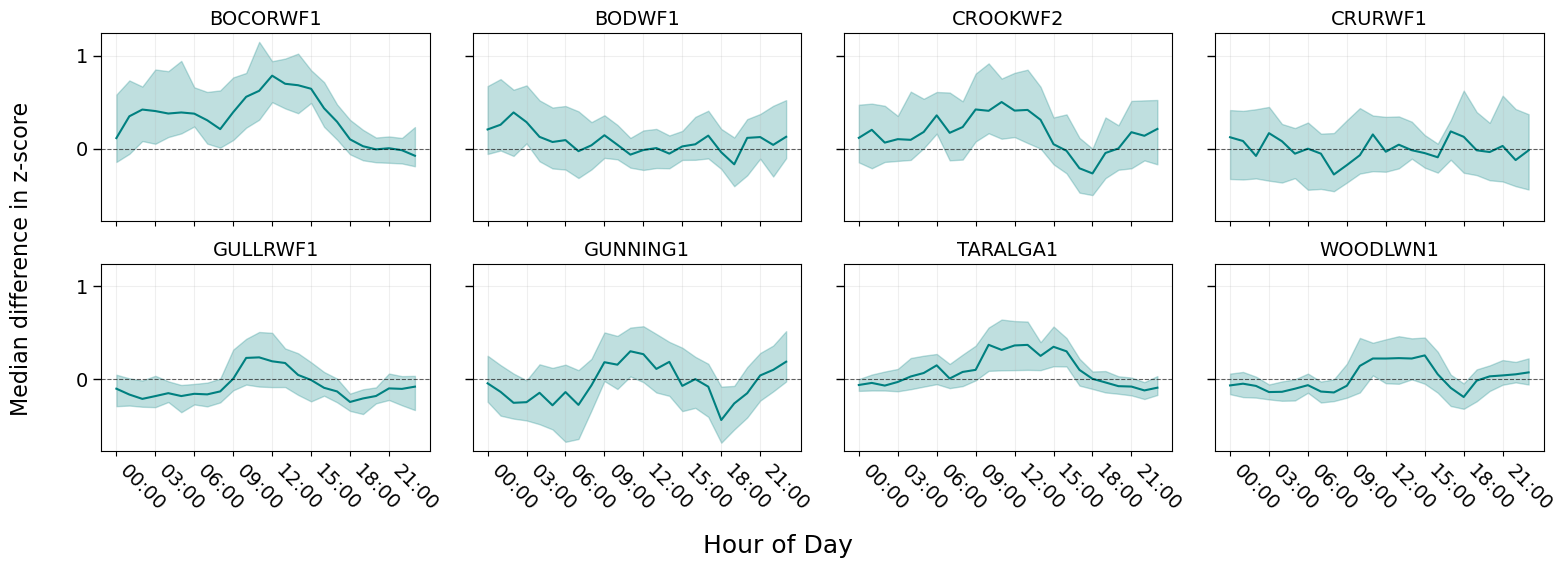

In [20]:
plot_duid_diffs_faceted(diff_results, cluster_name=3, metric="mean")
plot_duid_diffs_faceted(diff_results, cluster_name=3, metric="median")

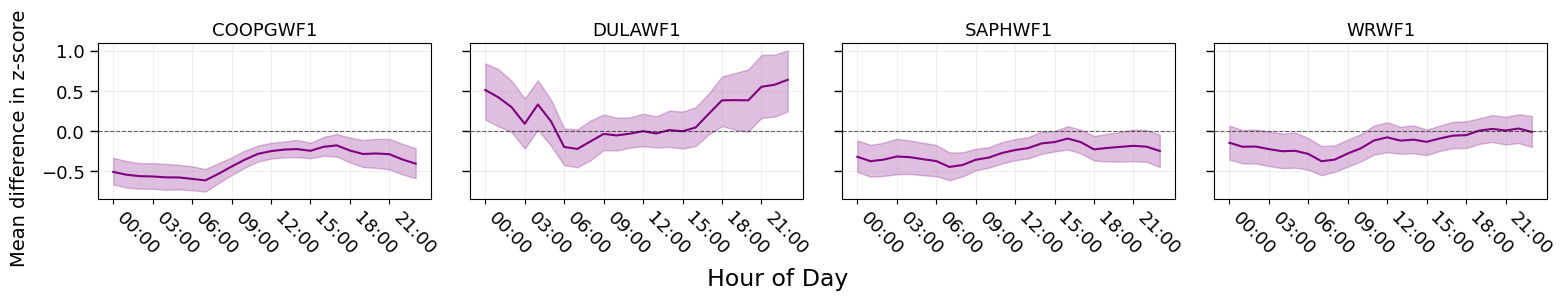

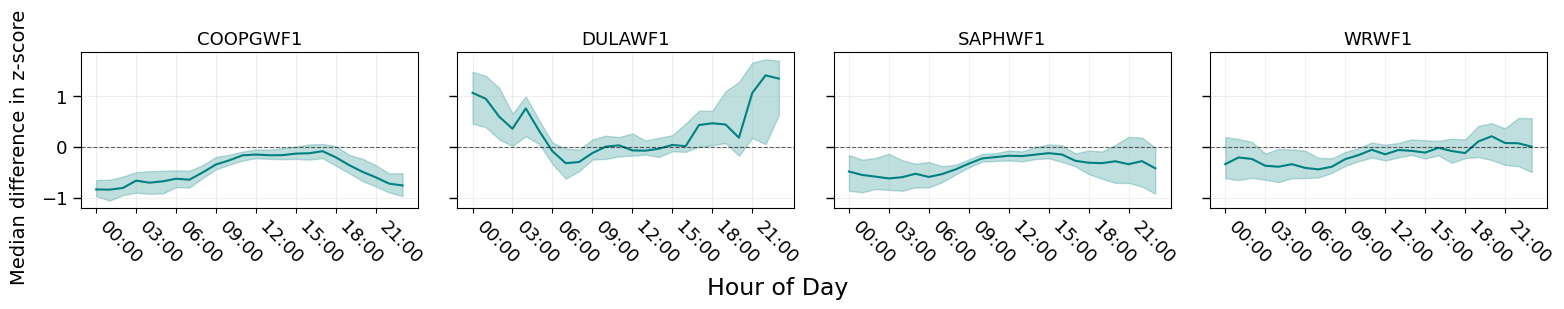

In [21]:
plot_duid_diffs_faceted(diff_results, cluster_name=4, metric="mean")
plot_duid_diffs_faceted(diff_results, cluster_name=4, metric="median")

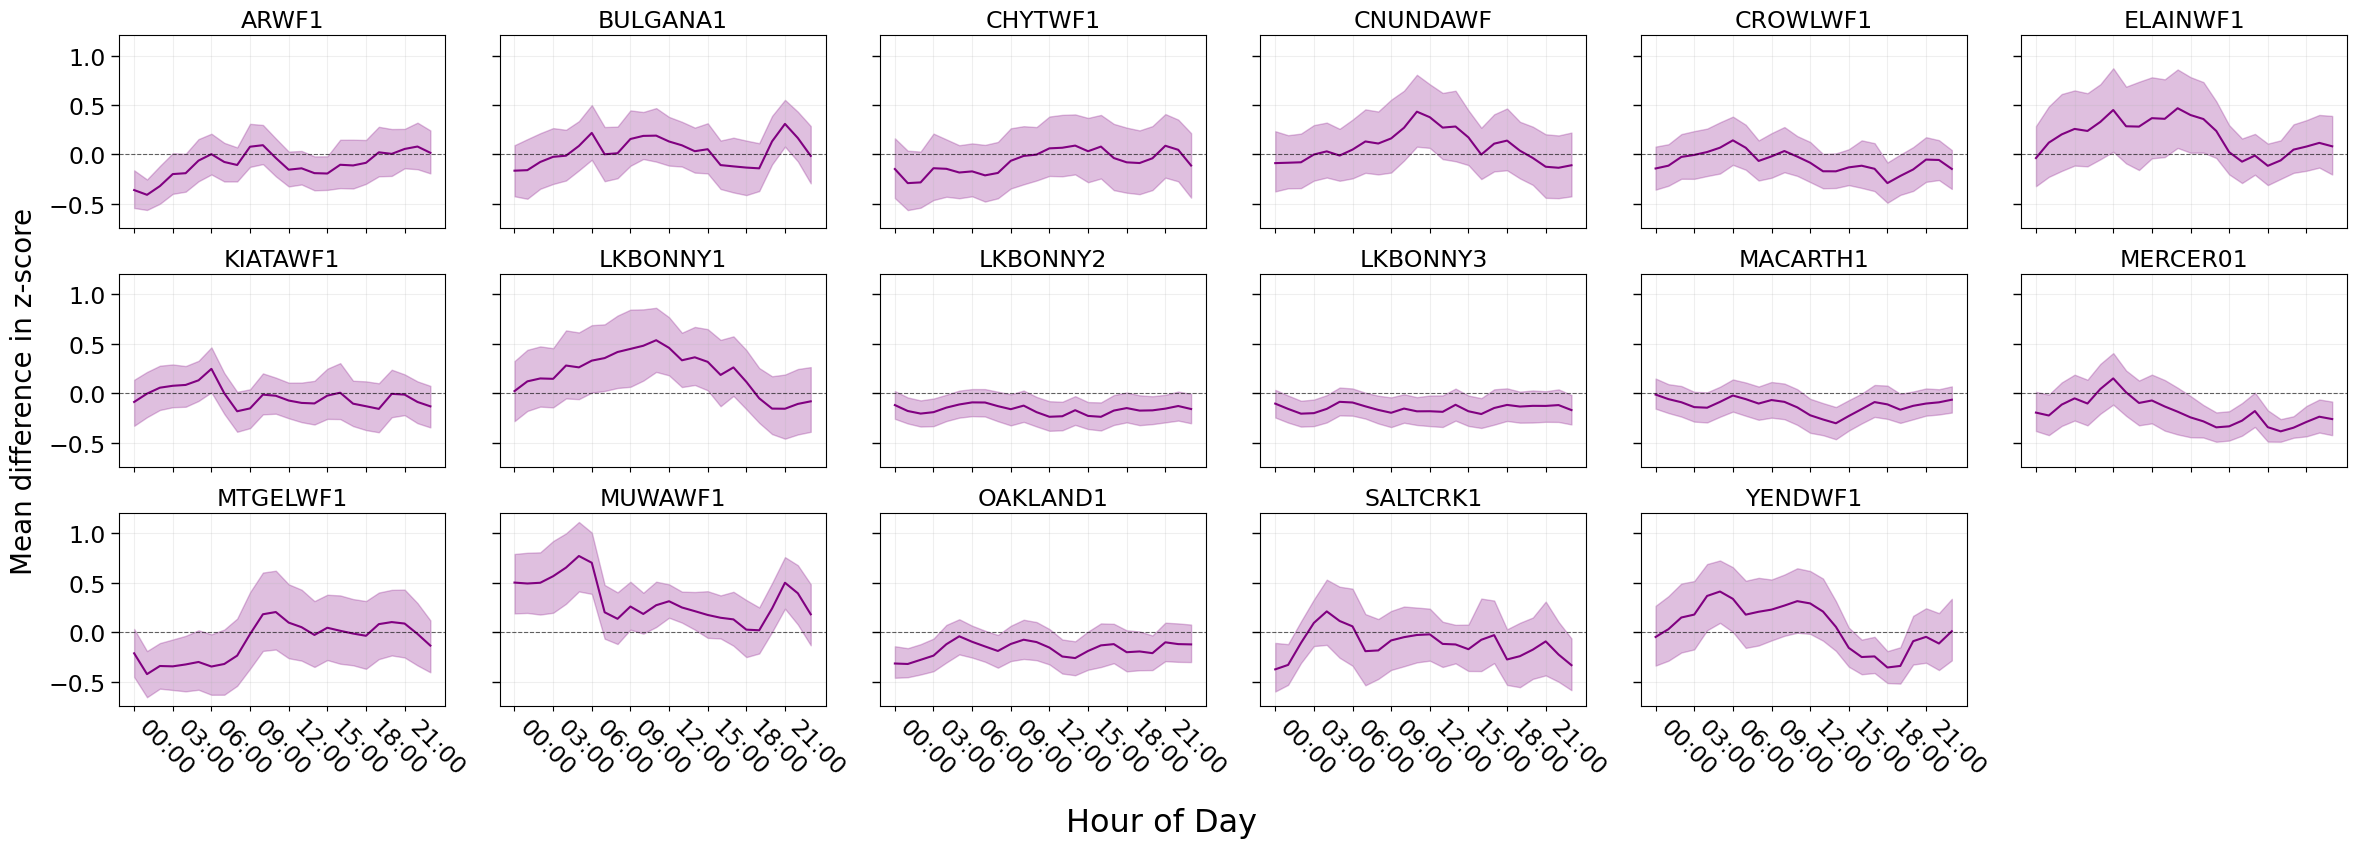

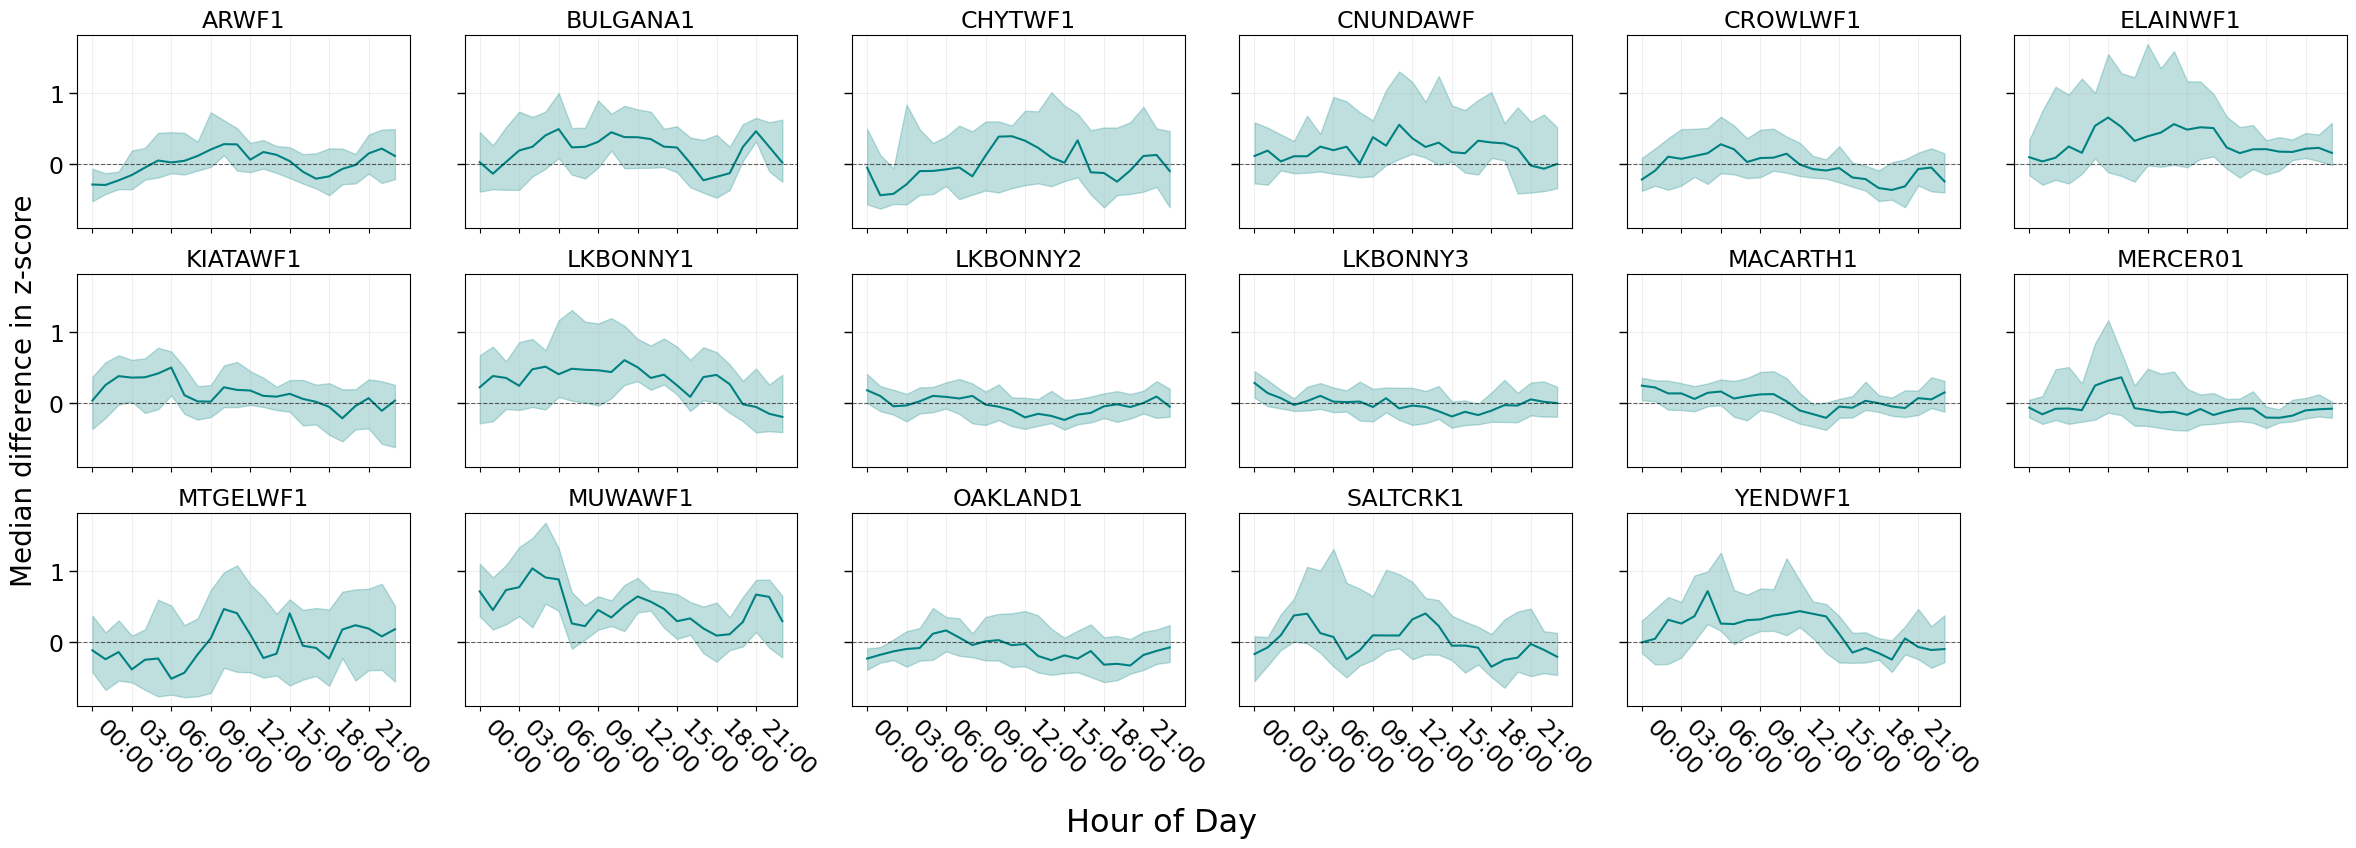

In [22]:
plot_duid_diffs_faceted(diff_results, ncols=6, cluster_name=5, metric="mean")
plot_duid_diffs_faceted(diff_results, ncols=6, cluster_name=5, metric="median")

In [23]:
diff_results.to_csv('/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/wind_difference_curves.csv', index=False)

In [24]:
# Build DUID × hour matrix from median_diff for PCA
pca_input = (
    diff_results
    .pivot_table(index='DUID', columns='hour', values='median_diff')
    .dropna(axis=0)  # drop DUIDs with incomplete curves
    .sort_index()
)

duid_index = pca_input.index.to_numpy()
X = pca_input.to_numpy()

# Standardise hours before PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Fit PCA (adjust n_components as needed)
pca = PCA(n_components=3, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(
    X_pca,
    index=duid_index,
    columns=[f'PC{i+1}' for i in range(X_pca.shape[1])]
).reset_index().rename(columns={'index': 'DUID'})

print('Explained variance ratio:', pca.explained_variance_ratio_)
pca_df.head()

Explained variance ratio: [0.62559586 0.14995558 0.08395946]


,DUID,PC1,PC2,PC3
0,ARWF1,0.302982,0.939694,-0.165073
1,BALDHWF1,-1.532732,-1.718722,1.943297
2,BLUFF1,-0.125805,0.039589,0.691015
3,BOCORWF1,5.473362,4.138273,-0.360257
4,BODWF1,1.124822,-0.908905,0.783049


In [25]:
# Optionally save PCA scores for later analysis
pca_df.to_csv(
    '/g/data/ng72/ms5578/ID_HW_BARRA/data/preprocess/wind_difference_pca.csv',
    index=False
)

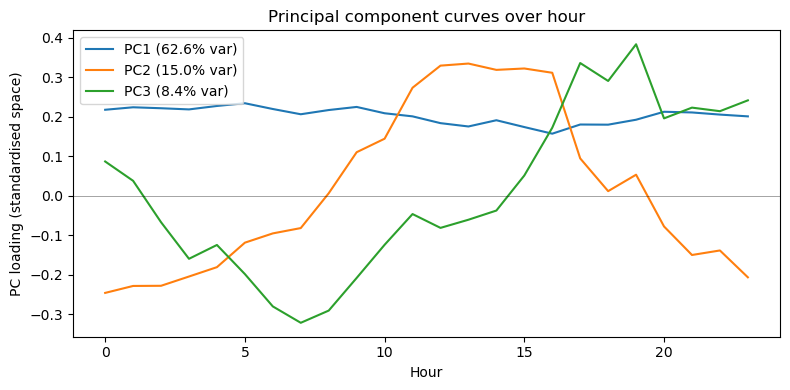

In [26]:
# Plot the first few principal component "curves" over hour
hours = pca_input.columns.to_numpy()

plt.figure(figsize=(8, 4))
for i in range(min(3, pca.components_.shape[0])):
    pc = pca.components_[i]
    plt.plot(hours, pc, label=f"PC{i+1} ({pca.explained_variance_ratio_[i]:.1%} var)")

plt.axhline(0, color="k", lw=0.5, alpha=0.5)
plt.xlabel("Hour")
plt.ylabel("PC loading (standardised space)")
plt.title("Principal component curves over hour")
plt.legend()
plt.tight_layout()
plt.show()

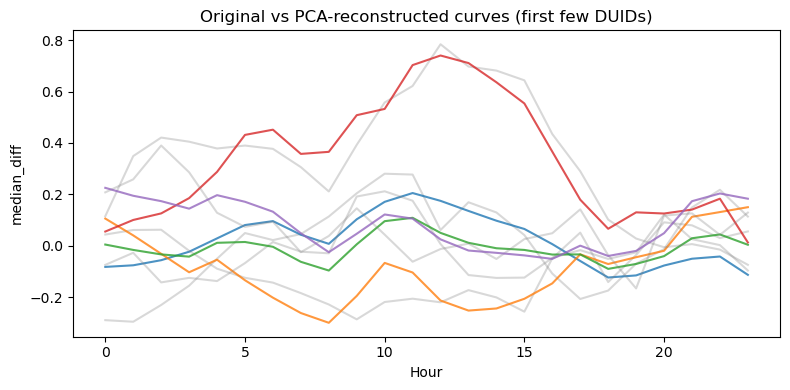

In [27]:
# Reconstruct example DUID curves using the first few PCs
n_components_to_use = 3

# Reconstruct in standardised space using only the first PCs
X_recon_scaled = X_pca[:, :n_components_to_use] @ pca.components_[:n_components_to_use, :]
X_recon = scaler.inverse_transform(X_recon_scaled)

example_idx = range(min(5, X.shape[0]))  # first few DUIDs

plt.figure(figsize=(8, 4))
for idx in example_idx:
    plt.plot(hours, X[idx, :], color="grey", alpha=0.3)
    plt.plot(hours, X_recon[idx, :], alpha=0.8)

plt.xlabel("Hour")
plt.ylabel("median_diff")
plt.title("Original vs PCA-reconstructed curves (first few DUIDs)")
plt.tight_layout()
plt.show()

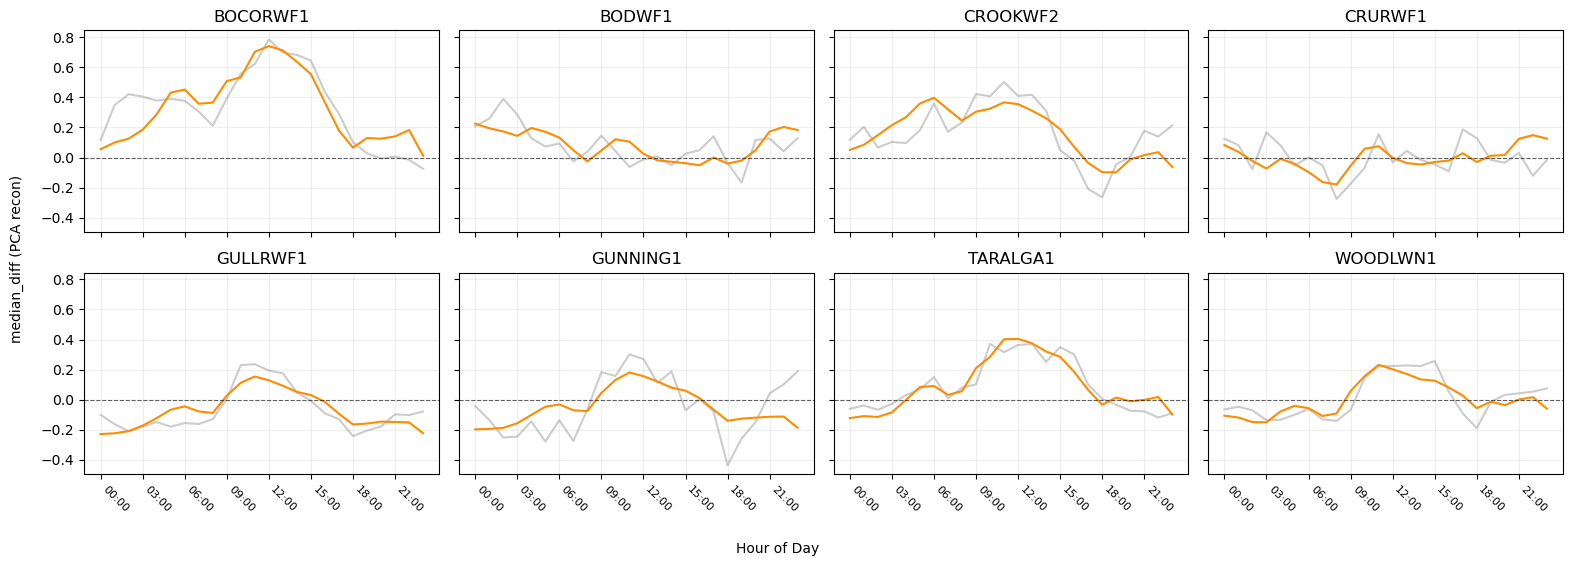

In [31]:
def plot_pca_duid_curves_faceted(
    cluster_name,
    ncols: int = 4,
    overlay_original: bool = True,
):
    """
    Faceted plot of PCA-reconstructed median_diff curves per DUID in a cluster,
    similar to plot_duid_diffs_faceted.
    """
    # Rebuild PCA-reconstructed curves as DataFrame (DUID × hour)
    recon_df = pd.DataFrame(
        X_recon,
        index=duid_index,
        columns=pca_input.columns,
    )

    # Map each DUID to its original spatial cluster
    duid_cluster = diff_results.groupby('DUID')['cluster'].first()

    duids = [
        d for d in duid_cluster.index[duid_cluster == cluster_name]
        if d in recon_df.index
    ]
    if not duids:
        raise ValueError(f"No PCA curves for cluster {cluster_name}")

    n_duids = len(duids)
    hours = recon_df.columns.to_numpy()

    nrows = int(np.ceil(n_duids / ncols))
    fig, axes = plt.subplots(
        nrows=nrows,
        ncols=ncols,
        figsize=(4.0 * ncols, 3.0 * nrows),
        sharex=True,
        sharey=True,
    )
    axes = np.array(axes).reshape(-1)

    for ax_idx, duid in enumerate(duids):
        ax = axes[ax_idx]

        y_pca = recon_df.loc[duid].values

        if overlay_original and duid in pca_input.index:
            y_orig = pca_input.loc[duid].values
            ax.plot(hours, y_orig, color='grey', alpha=0.4, label='original')

        ax.plot(hours, y_pca, color='darkorange', label='PCA recon')

        ax.axhline(0.0, color='black', linewidth=0.8, linestyle='--', alpha=0.6)
        ax.set_title(str(duid))

        tick_hours = range(0, 24, 3)
        tick_labels = [f"{h:02d}:00" for h in tick_hours]
        ax.set_xticks(tick_hours)
        ax.set_xticklabels(tick_labels, rotation=315, ha='left', fontsize=8)
        ax.grid(True, alpha=0.2)

    # Remove unused axes if any
    for ax in axes[n_duids:]:
        ax.remove()

    fig.text(0.5, 0.01, 'Hour of Day', ha='center')
    fig.text(0.02, 0.5, 'median_diff (PCA recon)', va='center', rotation='vertical')

    plt.tight_layout(rect=[0.03, 0.05, 1, 0.94])
    plt.show()

# Example usage:
plot_pca_duid_curves_faceted(cluster_name=3, ncols=4, overlay_original=True)